In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

In [3]:
query = "SELECT * FROM air_quality"

df = pd.read_sql_query(query, conn)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         290 non-null    int64  
 1   timestamp  290 non-null    object 
 2   aqi        290 non-null    int64  
 3   pm2_5      290 non-null    float64
 4   pm10       290 non-null    float64
 5   co         290 non-null    float64
 6   no2        290 non-null    float64
 7   o3         290 non-null    float64
 8   so2        290 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 20.5+ KB


In [5]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,145.500000,3.103448,40.674448,46.189586,605.766586,14.631931,53.012793,6.477793
std,83.860002,0.942823,20.286700,23.377907,245.465816,7.952892,34.202536,1.675684
min,1.000000,1.000000,7.140000,8.460000,248.980000,1.890000,0.220000,2.820000
25%,73.250000,3.000000,27.380000,30.110000,385.995000,8.347500,25.740000,5.220000
50%,145.500000,3.000000,37.330000,40.355000,584.180000,14.185000,50.605000,6.465000
75%,217.750000,4.000000,54.415000,62.230000,748.375000,19.667500,73.500000,7.625000
max,290.000000,5.000000,97.470000,119.310000,1310.840000,31.780000,146.150000,12.520000


In [6]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

id                    int64
timestamp    datetime64[ns]
aqi                   int64
pm2_5               float64
pm10                float64
co                  float64
no2                 float64
o3                  float64
so2                 float64
dtype: object

In [13]:
#feature engineering
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
285,286,2026-08-12 20:03:47,5,76.39,86.53,563.66,12.55,84.04,8.55,20,12,Wednesday
286,287,2026-08-12 20:23:58,5,79.12,90.80,627.42,13.80,72.78,8.96,20,12,Wednesday
287,288,2026-08-12 21:03:47,5,79.12,90.80,627.42,13.80,72.78,8.96,21,12,Wednesday
288,289,2026-08-12 22:03:44,5,80.29,93.23,674.34,14.59,62.94,8.88,22,12,Wednesday
289,290,2026-08-13 11:03:48,5,82.49,87.27,707.44,13.01,62.08,8.37,11,13,Thursday


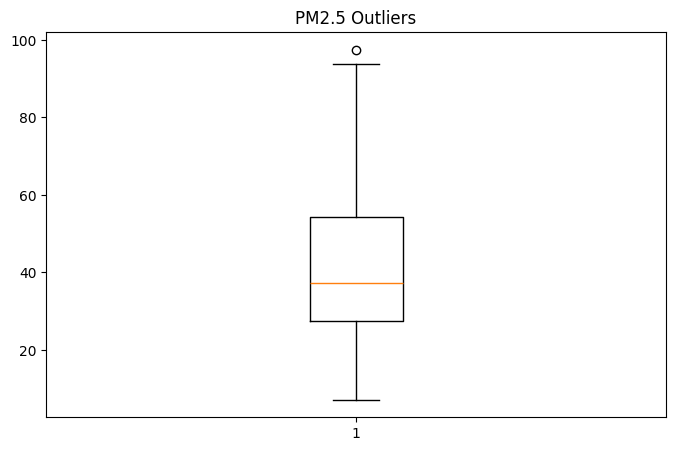

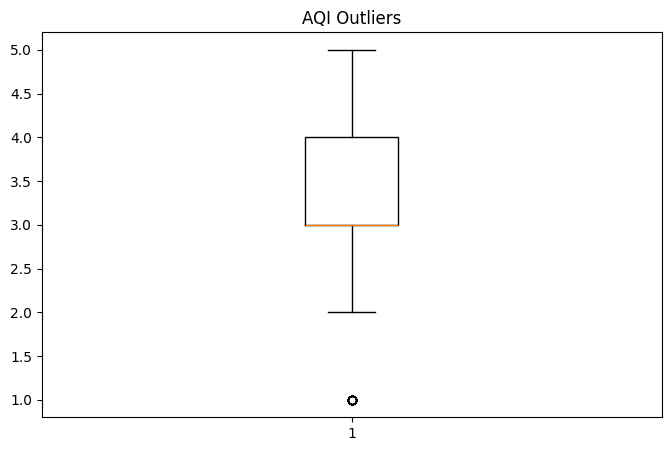

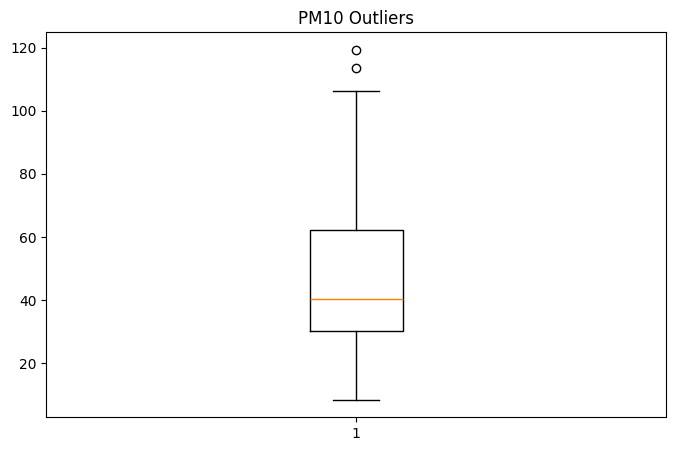

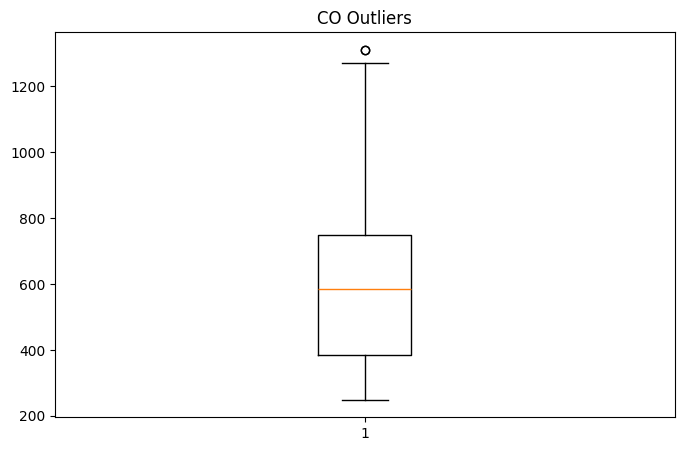

In [14]:
#checking for outliers using boxplots
plt.figure(figsize=(8,5))
plt.boxplot(df["pm2_5"])
plt.title("PM2.5 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["aqi"])
plt.title("AQI Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["pm10"])
plt.title("PM10 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["co"])
plt.title("CO Outliers")
plt.show()



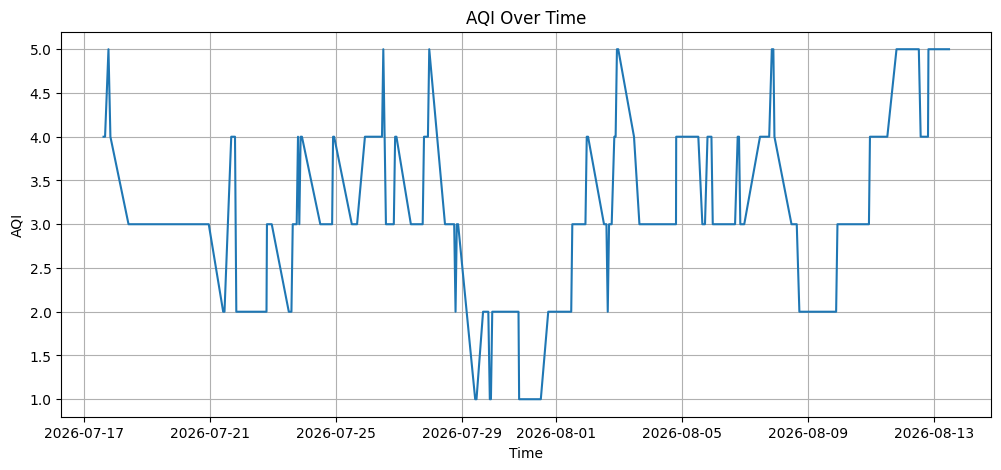

In [15]:
#aqi trend
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["aqi"])

plt.xlabel("Time")

plt.ylabel("AQI")

plt.title("AQI Over Time")

plt.grid(True)

plt.show()

In [16]:
#correlation matrix
corr = df.corr(numeric_only=True)
corr

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,0.221140,0.251618,0.275321,-0.035408,-0.129661,0.191906,0.223488,0.106090,-0.575678
aqi,0.221140,1.000000,0.942429,0.925777,0.524816,0.254661,0.182463,0.577323,0.039715,-0.382746
pm2_5,0.251618,0.942429,1.000000,0.989728,0.557643,0.277952,0.184373,0.638232,0.087475,-0.386968
pm10,0.275321,0.925777,0.989728,1.000000,0.609499,0.343653,0.105990,0.690788,0.157128,-0.390677
co,-0.035408,0.524816,0.557643,0.609499,1.000000,0.890230,-0.652902,0.726330,0.137836,-0.397359
no2,-0.129661,0.254661,0.277952,0.343653,0.890230,1.000000,-0.825591,0.670570,0.230496,-0.233947
o3,0.191906,0.182463,0.184373,0.105990,-0.652902,-0.825591,1.000000,-0.329399,-0.116077,0.141356
so2,0.223488,0.577323,0.638232,0.690788,0.726330,0.670570,-0.329399,1.000000,0.293183,-0.332080
hour,0.106090,0.039715,0.087475,0.157128,0.137836,0.230496,-0.116077,0.293183,1.000000,0.036374
day,-0.575678,-0.382746,-0.386968,-0.390677,-0.397359,-0.233947,0.141356,-0.332080,0.036374,1.000000


In [17]:
df.to_csv("../data/processed_air_quality.csv",index=False)

In [18]:
df.to_sql(
    "processed_air_quality",
    conn,
    if_exists="replace",
    index=False
)

290

In [19]:
conn.close()